# Telangana Fair Price Shop (FPS) Performance Clustering

## Business Problem

The Telangana State Civil Supplies Department manages thousands of Fair Price Shops (FPS) to ensure food security across the state.

Analyzing the performance of these shops manually is difficult due to the large volume of transaction, card entitlement, and geospatial data.

The objective of this project is to integrate multiple datasets, perform exploratory data analysis, engineer meaningful features, apply clustering techniques (K-Means and DBSCAN), and build an interactive Streamlit dashboard to monitor shop performance and identify behavioral patterns.

---

## Objectives

- Integrate multiple monthly datasets
- Perform comprehensive Exploratory Data Analysis
- Engineer meaningful business features
- Apply PCA for dimensionality reduction
- Perform K-Means & DBSCAN clustering
- Profile shop clusters
- Build an interactive Streamlit Dashboard

In [23]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import os
import glob
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot Style
plt.style.use("ggplot")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [24]:
# ==========================================================
# Dataset Paths
# ==========================================================

transaction_path = "../data/raw/transactions"
card_status_path = "../data/raw/card_status"
location_path = "../data/raw/locations"

print("Transaction Path :", transaction_path)
print("Card Status Path :", card_status_path)
print("Location Path :", location_path)

Transaction Path : ../data/raw/transactions
Card Status Path : ../data/raw/card_status
Location Path : ../data/raw/locations


In [25]:
# ==========================================================
# Read All CSV Files
# ==========================================================

transaction_files = sorted(glob.glob(os.path.join(transaction_path, "*.csv")))
card_files = sorted(glob.glob(os.path.join(card_status_path, "*.csv")))
location_files = sorted(glob.glob(os.path.join(location_path, "*.csv")))

print(f"Transaction Files : {len(transaction_files)}")
print(f"Card Status Files : {len(card_files)}")
print(f"Location Files : {len(location_files)}")

Transaction Files : 5
Card Status Files : 5
Location Files : 1


In [26]:
# ==========================================================
# Merge Transaction Files
# ==========================================================

transaction_list = []

for file in transaction_files:
    df = pd.read_csv(file)
    transaction_list.append(df)

transactions = pd.concat(transaction_list, ignore_index=True)

print("Transaction Dataset Shape :", transactions.shape)

transactions.head()

Transaction Dataset Shape : (86219, 19)


,distCode,distName,officeCode,officeName,shopNo,month,year,noOfRcs,noOfTrans,riceAfsc,riceFsc,riceAap,wheat,sugar,rgdal,kerosene,totalAmount,salt,otherShopTransCnt
0,532,Adilabad,532001,Talamadugu,1901001,1,2025,885,885,1365.0,16176.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28
1,532,Adilabad,532001,Talamadugu,1901002,1,2025,510,510,665.0,9576.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31
2,532,Adilabad,532001,Talamadugu,1901003,1,2025,263,264,525.0,4878.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23
3,532,Adilabad,532001,Talamadugu,1901004,1,2025,361,363,490.0,7026.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,11
4,532,Adilabad,532001,Talamadugu,1901005,1,2025,896,899,5145.0,15784.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33


In [27]:
# ==========================================================
# Merge Card Status Files
# ==========================================================

card_list = []

for file in card_files:
    df = pd.read_csv(file)
    card_list.append(df)

card_status = pd.concat(card_list, ignore_index=True)

print("Card Status Shape :", card_status.shape)

card_status.head()

Card Status Shape : (86313, 28)


,distCode,distName,officeCode,officeName,shopNo,month,year,rcNfsaAay,unitsNfsaAay,rcNfsaPhh,unitsNfsaPhh,totalRcNfsa,totalUnitsNfsa,rcStateAay,unitsStateAay,rcStatePhh,unitsStatePhh,rcStateAap,unitsStateAap,totalRcState,totalUnitsState,totalRcs,totalUnits,cardTypeId,units,gasCylinders,mroAsoApprDate,cardPoolType
0,532,Adilabad,532001,Talamadugu,1901001,1,2025,39,129,920,2955,959,3084,0,0,149,304,0,0,149,304,1108,3388,NaN,0,0,NaN,NaN
1,532,Adilabad,532001,Talamadugu,1901002,1,2025,20,69,258,1067,278,1136,0,0,306,736,0,0,306,736,584,1872,NaN,0,0,NaN,NaN
2,532,Adilabad,532001,Talamadugu,1901003,1,2025,17,60,158,596,175,656,0,0,117,295,0,0,117,295,292,951,NaN,0,0,NaN,NaN
3,532,Adilabad,532001,Talamadugu,1901004,1,2025,14,45,190,772,204,817,0,0,200,525,1,1,201,526,405,1343,NaN,0,0,NaN,NaN
4,532,Adilabad,532001,Talamadugu,1901005,1,2025,155,520,530,2046,685,2566,0,0,285,740,0,0,285,740,970,3306,NaN,0,0,NaN,NaN


In [28]:
# ==========================================================
# Read Shop Status Dataset
# ==========================================================

shop_status = pd.read_csv(location_files[0])

print("Shop Status Shape :", shop_status.shape)

shop_status.head()

Shop Status Shape : (17434, 11)


,distCode,distName,officeCode,officeName,shopNo,address,longitude,latitude,fpsStatus,fpsType,dateTime
0,532,Adilabad,532001,Talamadugu,1901001,DR Depo TALAMADUGU Talamadugu,78.391212,19.641643,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
1,532,Adilabad,532001,Talamadugu,1901002,Sunkari Ramesh Sunkidi,78.422012,19.669093,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
2,532,Adilabad,532001,Talamadugu,1901003,Sakipelli Gajanan Umdam,78.427186,19.664645,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
3,532,Adilabad,532001,Talamadugu,1901004,Rebbathi Rakesh Lingi,78.381016,19.696032,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
4,532,Adilabad,532001,Talamadugu,1901005,T Manohar Kuchulapur,78.351118,19.697063,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30


In [29]:
# ==========================================================
# Save Master Datasets
# ==========================================================

os.makedirs("../data/processed", exist_ok=True)

transactions.to_csv("../data/processed/master_transactions.csv", index=False)

card_status.to_csv("../data/processed/master_card_status.csv", index=False)

shop_status.to_csv("../data/processed/master_shop_status.csv", index=False)

print("Master datasets saved successfully!")

Master datasets saved successfully!


In [30]:
# ==========================================================
# Dataset Information
# ==========================================================

print("="*60)
print("TRANSACTIONS DATASET")
print("="*60)

transactions.info()

print("\n")

print("="*60)
print("CARD STATUS DATASET")
print("="*60)

card_status.info()

print("\n")

print("="*60)
print("SHOP STATUS DATASET")
print("="*60)

shop_status.info()

TRANSACTIONS DATASET
<class 'pandas.DataFrame'>
RangeIndex: 86219 entries, 0 to 86218
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   distCode           86219 non-null  int64  
 1   distName           86219 non-null  str    
 2   officeCode         86219 non-null  int64  
 3   officeName         86219 non-null  str    
 4   shopNo             86219 non-null  int64  
 5   month              86219 non-null  int64  
 6   year               86219 non-null  int64  
 7   noOfRcs            86219 non-null  int64  
 8   noOfTrans          86219 non-null  int64  
 9   riceAfsc           86219 non-null  float64
 10  riceFsc            86219 non-null  float64
 11  riceAap            86219 non-null  float64
 12  wheat              86219 non-null  float64
 13  sugar              86219 non-null  float64
 14  rgdal              86219 non-null  float64
 15  kerosene           86219 non-null  float64
 16  totalAmount 

In [31]:
# ==========================================================
# Statistical Summary
# ==========================================================

transactions.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
distCode,86219.0,NaN,NaN,NaN,785.38459,192.472603,532.0,539.0,926.0,934.0,982.0
distName,86219,33,Nalgonda,4983,NaN,NaN,NaN,NaN,NaN,NaN,NaN
officeCode,86219.0,NaN,NaN,NaN,785408.500806,192456.816785,532001.0,539012.0,926011.0,934023.0,982012.0
officeName,86219,585,Balanagar-1,1135,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shopNo,86219.0,NaN,NaN,NaN,2920216.983055,934626.802011,1407001.0,2109030.0,2911026.0,3723020.0,4612012.0
month,86219.0,NaN,NaN,NaN,3.00058,1.414287,1.0,2.0,3.0,4.0,5.0
year,86219.0,NaN,NaN,NaN,2025.0,0.0,2025.0,2025.0,2025.0,2025.0,2025.0
noOfRcs,86219.0,NaN,NaN,NaN,454.091059,283.641501,1.0,278.5,394.0,547.0,7086.0
noOfTrans,86219.0,NaN,NaN,NaN,455.653128,284.593652,1.0,280.0,396.0,549.0,7089.0
riceAfsc,86219.0,NaN,NaN,NaN,1098.311265,798.489486,0.0,595.0,910.0,1365.0,10145.0


In [32]:
card_status.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
distCode,86313.0,NaN,NaN,NaN,785.357304,192.477702,532.0,539.0,926.0,934.0,982.0
distName,86313,33,Nalgonda,4985,NaN,NaN,NaN,NaN,NaN,NaN,NaN
officeCode,86313.0,NaN,NaN,NaN,785381.213212,192461.919368,532001.0,539012.0,926011.0,934023.0,982012.0
officeName,86313,585,Balanagar-1,1135,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shopNo,86313.0,NaN,NaN,NaN,2920151.379618,934505.66006,1407001.0,2109031.0,2911027.0,3723018.0,4612012.0
month,86313.0,NaN,NaN,NaN,2.999965,1.414218,1.0,2.0,3.0,4.0,5.0
year,86313.0,NaN,NaN,NaN,2025.0,0.0,2025.0,2025.0,2025.0,2025.0,2025.0
rcNfsaAay,86313.0,NaN,NaN,NaN,32.826515,22.625018,0.0,19.0,28.0,41.0,276.0
unitsNfsaAay,86313.0,NaN,NaN,NaN,93.181861,67.961028,0.0,50.0,78.0,116.0,920.0
rcNfsaPhh,86313.0,NaN,NaN,NaN,283.827859,160.017843,0.0,174.0,251.0,359.0,2407.0


In [33]:
shop_status.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
distCode,17434.0,NaN,NaN,NaN,785.875473,192.364599,532.0,539.0,926.0,934.0,982.0
distName,17434,33,Nalgonda,997,NaN,NaN,NaN,NaN,NaN,NaN,NaN
officeCode,17434.0,NaN,NaN,NaN,785899.539062,192348.637736,532001.0,539012.0,926014.0,934025.0,982012.0
officeName,17434,592,Balanagar-1,227,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shopNo,17434.0,NaN,NaN,NaN,2920379.34404,945995.903734,3128.0,2109028.25,2914007.5,3725002.75,4612012.0
address,17422,17352,GCC ETURNAGARAM,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
longitude,17368.0,NaN,NaN,NaN,77.157367,11.534685,0.0,78.212417,78.705278,79.487733,81.26347
latitude,17368.0,NaN,NaN,NaN,17.35873,2.701284,0.0,17.141632,17.603908,18.321973,19.880502
fpsStatus,17434,1,Active,17434,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fpsType,17434,2,Normal Shop,17262,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
# ==========================================================
# Missing Values
# ==========================================================

transactions.isnull().sum().sort_values(ascending=False)

distCode             0
distName             0
officeCode           0
officeName           0
shopNo               0
month                0
year                 0
noOfRcs              0
noOfTrans            0
riceAfsc             0
riceFsc              0
riceAap              0
wheat                0
sugar                0
rgdal                0
kerosene             0
totalAmount          0
salt                 0
otherShopTransCnt    0
dtype: int64

In [35]:
card_status.isnull().sum().sort_values(ascending=False)

mroAsoApprDate     86313
cardTypeId         86313
cardPoolType       86313
distCode               0
shopNo                 0
month                  0
year                   0
rcNfsaAay              0
unitsNfsaAay           0
distName               0
officeCode             0
officeName             0
totalRcNfsa            0
unitsNfsaPhh           0
rcNfsaPhh              0
totalUnitsNfsa         0
unitsStatePhh          0
rcStateAay             0
unitsStateAay          0
rcStatePhh             0
totalRcState           0
unitsStateAap          0
rcStateAap             0
totalUnitsState        0
totalUnits             0
totalRcs               0
gasCylinders           0
units                  0
dtype: int64

In [36]:
shop_status.isnull().sum().sort_values(ascending=False)

longitude     66
latitude      66
address       12
officeCode     0
distName       0
distCode       0
shopNo         0
officeName     0
fpsStatus      0
fpsType        0
dateTime       0
dtype: int64

In [37]:
# ==========================================================
# Duplicate Records
# ==========================================================

print("Transaction Duplicates :", transactions.duplicated().sum())

print("Card Status Duplicates :", card_status.duplicated().sum())

print("Shop Status Duplicates :", shop_status.duplicated().sum())

Transaction Duplicates : 0
Card Status Duplicates : 0
Shop Status Duplicates : 0


In [38]:
# ==========================================================
# Dataset Dimensions
# ==========================================================

datasets = {
    "Transactions": transactions,
    "Card Status": card_status,
    "Shop Status": shop_status
}

for name, df in datasets.items():
    print(f"\n{name}")
    print("-"*40)
    print(f"Rows : {df.shape[0]}")
    print(f"Columns : {df.shape[1]}")


Transactions
----------------------------------------
Rows : 86219
Columns : 19

Card Status
----------------------------------------
Rows : 86313
Columns : 28

Shop Status
----------------------------------------
Rows : 17434
Columns : 11


In [39]:
print(transactions.columns.tolist())

['distCode', 'distName', 'officeCode', 'officeName', 'shopNo', 'month', 'year', 'noOfRcs', 'noOfTrans', 'riceAfsc', 'riceFsc', 'riceAap', 'wheat', 'sugar', 'rgdal', 'kerosene', 'totalAmount', 'salt', 'otherShopTransCnt']


In [40]:
print(card_status.columns.tolist())

['distCode', 'distName', 'officeCode', 'officeName', 'shopNo', 'month', 'year', 'rcNfsaAay', 'unitsNfsaAay', 'rcNfsaPhh', 'unitsNfsaPhh', 'totalRcNfsa', 'totalUnitsNfsa', 'rcStateAay', 'unitsStateAay', 'rcStatePhh', 'unitsStatePhh', 'rcStateAap', 'unitsStateAap', 'totalRcState', 'totalUnitsState', 'totalRcs', 'totalUnits', 'cardTypeId', 'units', 'gasCylinders', 'mroAsoApprDate', 'cardPoolType']


In [41]:
print(shop_status.columns.tolist())

['distCode', 'distName', 'officeCode', 'officeName', 'shopNo', 'address', 'longitude', 'latitude', 'fpsStatus', 'fpsType', 'dateTime']


## Data Cleaning and Data Integration

In [42]:
# ==========================================================
# Remove Duplicate Records
# ==========================================================

transactions.drop_duplicates(inplace=True)

card_status.drop_duplicates(inplace=True)

shop_status.drop_duplicates(inplace=True)

print("Duplicates removed successfully.")

Duplicates removed successfully.


In [43]:
# ==========================================================
# Merge Transactions and Card Status
# ==========================================================

merged_df = pd.merge(
    transactions,
    card_status,
    on=["distCode", "shopNo", "month", "year"],
    how="inner",
    suffixes=("_trans", "_card")
)

print("Merged Shape:", merged_df.shape)
merged_df.head()

Merged Shape: (86219, 43)


,distCode,distName_trans,officeCode_trans,officeName_trans,shopNo,month,year,noOfRcs,noOfTrans,riceAfsc,riceFsc,riceAap,wheat,sugar,rgdal,kerosene,totalAmount,salt,otherShopTransCnt,distName_card,officeCode_card,officeName_card,rcNfsaAay,unitsNfsaAay,rcNfsaPhh,unitsNfsaPhh,totalRcNfsa,totalUnitsNfsa,rcStateAay,unitsStateAay,rcStatePhh,unitsStatePhh,rcStateAap,unitsStateAap,totalRcState,totalUnitsState,totalRcs,totalUnits,cardTypeId,units,gasCylinders,mroAsoApprDate,cardPoolType
0,532,Adilabad,532001,Talamadugu,1901001,1,2025,885,885,1365.0,16176.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28,Adilabad,532001,Talamadugu,39,129,920,2955,959,3084,0,0,149,304,0,0,149,304,1108,3388,NaN,0,0,NaN,NaN
1,532,Adilabad,532001,Talamadugu,1901002,1,2025,510,510,665.0,9576.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31,Adilabad,532001,Talamadugu,20,69,258,1067,278,1136,0,0,306,736,0,0,306,736,584,1872,NaN,0,0,NaN,NaN
2,532,Adilabad,532001,Talamadugu,1901003,1,2025,263,264,525.0,4878.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23,Adilabad,532001,Talamadugu,17,60,158,596,175,656,0,0,117,295,0,0,117,295,292,951,NaN,0,0,NaN,NaN
3,532,Adilabad,532001,Talamadugu,1901004,1,2025,361,363,490.0,7026.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,11,Adilabad,532001,Talamadugu,14,45,190,772,204,817,0,0,200,525,1,1,201,526,405,1343,NaN,0,0,NaN,NaN
4,532,Adilabad,532001,Talamadugu,1901005,1,2025,896,899,5145.0,15784.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33,Adilabad,532001,Talamadugu,155,520,530,2046,685,2566,0,0,285,740,0,0,285,740,970,3306,NaN,0,0,NaN,NaN


In [44]:
# ==========================================================
# Merge Shop Status Dataset
# ==========================================================

final_df = pd.merge(
    merged_df,
    shop_status,
    on=["distCode", "shopNo"],
    how="left"
)

print("Final Dataset Shape:", final_df.shape)
final_df.head()

Final Dataset Shape: (86219, 52)


,distCode,distName_trans,officeCode_trans,officeName_trans,shopNo,month,year,noOfRcs,noOfTrans,riceAfsc,riceFsc,riceAap,wheat,sugar,rgdal,kerosene,totalAmount,salt,otherShopTransCnt,distName_card,officeCode_card,officeName_card,rcNfsaAay,unitsNfsaAay,rcNfsaPhh,unitsNfsaPhh,totalRcNfsa,totalUnitsNfsa,rcStateAay,unitsStateAay,rcStatePhh,unitsStatePhh,rcStateAap,unitsStateAap,totalRcState,totalUnitsState,totalRcs,totalUnits,cardTypeId,units,gasCylinders,mroAsoApprDate,cardPoolType,distName,officeCode,officeName,address,longitude,latitude,fpsStatus,fpsType,dateTime
0,532,Adilabad,532001,Talamadugu,1901001,1,2025,885,885,1365.0,16176.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28,Adilabad,532001,Talamadugu,39,129,920,2955,959,3084,0,0,149,304,0,0,149,304,1108,3388,NaN,0,0,NaN,NaN,Adilabad,532001.0,Talamadugu,DR Depo TALAMADUGU Talamadugu,78.391212,19.641643,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
1,532,Adilabad,532001,Talamadugu,1901002,1,2025,510,510,665.0,9576.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31,Adilabad,532001,Talamadugu,20,69,258,1067,278,1136,0,0,306,736,0,0,306,736,584,1872,NaN,0,0,NaN,NaN,Adilabad,532001.0,Talamadugu,Sunkari Ramesh Sunkidi,78.422012,19.669093,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
2,532,Adilabad,532001,Talamadugu,1901003,1,2025,263,264,525.0,4878.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23,Adilabad,532001,Talamadugu,17,60,158,596,175,656,0,0,117,295,0,0,117,295,292,951,NaN,0,0,NaN,NaN,Adilabad,532001.0,Talamadugu,Sakipelli Gajanan Umdam,78.427186,19.664645,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
3,532,Adilabad,532001,Talamadugu,1901004,1,2025,361,363,490.0,7026.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,11,Adilabad,532001,Talamadugu,14,45,190,772,204,817,0,0,200,525,1,1,201,526,405,1343,NaN,0,0,NaN,NaN,Adilabad,532001.0,Talamadugu,Rebbathi Rakesh Lingi,78.381016,19.696032,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
4,532,Adilabad,532001,Talamadugu,1901005,1,2025,896,899,5145.0,15784.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33,Adilabad,532001,Talamadugu,155,520,530,2046,685,2566,0,0,285,740,0,0,285,740,970,3306,NaN,0,0,NaN,NaN,Adilabad,532001.0,Talamadugu,T Manohar Kuchulapur,78.351118,19.697063,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30


In [45]:
# ==========================================================
# Save Final Dataset
# ==========================================================

final_df.to_csv("../data/processed/final_dataset.csv", index=False)

print("Final dataset saved successfully!")

Final dataset saved successfully!


In [46]:
# ==========================================================
# Remove Duplicate Records
# ==========================================================

transactions.drop_duplicates(inplace=True)
card_status.drop_duplicates(inplace=True)
shop_status.drop_duplicates(inplace=True)

print("Duplicate removal completed successfully!")

print("\nRemaining duplicates:")
print("Transactions :", transactions.duplicated().sum())
print("Card Status  :", card_status.duplicated().sum())
print("Shop Status  :", shop_status.duplicated().sum())

Duplicate removal completed successfully!

Remaining duplicates:
Transactions : 0
Card Status  : 0
Shop Status  : 0


In [47]:
# ==========================================================
# Merge Transaction and Card Status
# ==========================================================

card_required = card_status.drop(
    columns=["distName", "officeCode", "officeName"]
)

merged_df = pd.merge(
    transactions,
    card_required,
    on=["distCode", "shopNo", "month", "year"],
    how="inner"
)

print("Merged Dataset Shape :", merged_df.shape)

merged_df.head()

Merged Dataset Shape : (86219, 40)


,distCode,distName,officeCode,officeName,shopNo,month,year,noOfRcs,noOfTrans,riceAfsc,riceFsc,riceAap,wheat,sugar,rgdal,kerosene,totalAmount,salt,otherShopTransCnt,rcNfsaAay,unitsNfsaAay,rcNfsaPhh,unitsNfsaPhh,totalRcNfsa,totalUnitsNfsa,rcStateAay,unitsStateAay,rcStatePhh,unitsStatePhh,rcStateAap,unitsStateAap,totalRcState,totalUnitsState,totalRcs,totalUnits,cardTypeId,units,gasCylinders,mroAsoApprDate,cardPoolType
0,532,Adilabad,532001,Talamadugu,1901001,1,2025,885,885,1365.0,16176.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28,39,129,920,2955,959,3084,0,0,149,304,0,0,149,304,1108,3388,NaN,0,0,NaN,NaN
1,532,Adilabad,532001,Talamadugu,1901002,1,2025,510,510,665.0,9576.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31,20,69,258,1067,278,1136,0,0,306,736,0,0,306,736,584,1872,NaN,0,0,NaN,NaN
2,532,Adilabad,532001,Talamadugu,1901003,1,2025,263,264,525.0,4878.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23,17,60,158,596,175,656,0,0,117,295,0,0,117,295,292,951,NaN,0,0,NaN,NaN
3,532,Adilabad,532001,Talamadugu,1901004,1,2025,361,363,490.0,7026.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,11,14,45,190,772,204,817,0,0,200,525,1,1,201,526,405,1343,NaN,0,0,NaN,NaN
4,532,Adilabad,532001,Talamadugu,1901005,1,2025,896,899,5145.0,15784.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33,155,520,530,2046,685,2566,0,0,285,740,0,0,285,740,970,3306,NaN,0,0,NaN,NaN


In [48]:
# ==========================================================
# Merge Shop Status
# ==========================================================

shop_required = shop_status.drop(
    columns=["distName", "officeCode", "officeName"]
)

final_df = pd.merge(
    merged_df,
    shop_required,
    on=["distCode", "shopNo"],
    how="left"
)

print("Final Dataset Shape :", final_df.shape)

final_df.head()

Final Dataset Shape : (86219, 46)


,distCode,distName,officeCode,officeName,shopNo,month,year,noOfRcs,noOfTrans,riceAfsc,riceFsc,riceAap,wheat,sugar,rgdal,kerosene,totalAmount,salt,otherShopTransCnt,rcNfsaAay,unitsNfsaAay,rcNfsaPhh,unitsNfsaPhh,totalRcNfsa,totalUnitsNfsa,rcStateAay,unitsStateAay,rcStatePhh,unitsStatePhh,rcStateAap,unitsStateAap,totalRcState,totalUnitsState,totalRcs,totalUnits,cardTypeId,units,gasCylinders,mroAsoApprDate,cardPoolType,address,longitude,latitude,fpsStatus,fpsType,dateTime
0,532,Adilabad,532001,Talamadugu,1901001,1,2025,885,885,1365.0,16176.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28,39,129,920,2955,959,3084,0,0,149,304,0,0,149,304,1108,3388,NaN,0,0,NaN,NaN,DR Depo TALAMADUGU Talamadugu,78.391212,19.641643,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
1,532,Adilabad,532001,Talamadugu,1901002,1,2025,510,510,665.0,9576.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31,20,69,258,1067,278,1136,0,0,306,736,0,0,306,736,584,1872,NaN,0,0,NaN,NaN,Sunkari Ramesh Sunkidi,78.422012,19.669093,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
2,532,Adilabad,532001,Talamadugu,1901003,1,2025,263,264,525.0,4878.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23,17,60,158,596,175,656,0,0,117,295,0,0,117,295,292,951,NaN,0,0,NaN,NaN,Sakipelli Gajanan Umdam,78.427186,19.664645,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
3,532,Adilabad,532001,Talamadugu,1901004,1,2025,361,363,490.0,7026.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,11,14,45,190,772,204,817,0,0,200,525,1,1,201,526,405,1343,NaN,0,0,NaN,NaN,Rebbathi Rakesh Lingi,78.381016,19.696032,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
4,532,Adilabad,532001,Talamadugu,1901005,1,2025,896,899,5145.0,15784.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33,155,520,530,2046,685,2566,0,0,285,740,0,0,285,740,970,3306,NaN,0,0,NaN,NaN,T Manohar Kuchulapur,78.351118,19.697063,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30


In [49]:
# ==========================================================
# Save Processed Dataset
# ==========================================================

import os

os.makedirs("../data/processed", exist_ok=True)

final_df.to_csv("../data/processed/final_dataset.csv", index=False)

print("Final dataset saved successfully!")

Final dataset saved successfully!


In [50]:
# ==========================================================
# Final Dataset Overview
# ==========================================================

print("Dataset Shape :", final_df.shape)

print("\n")

final_df.info()

Dataset Shape : (86219, 46)


<class 'pandas.DataFrame'>
RangeIndex: 86219 entries, 0 to 86218
Data columns (total 46 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   distCode           86219 non-null  int64  
 1   distName           86219 non-null  str    
 2   officeCode         86219 non-null  int64  
 3   officeName         86219 non-null  str    
 4   shopNo             86219 non-null  int64  
 5   month              86219 non-null  int64  
 6   year               86219 non-null  int64  
 7   noOfRcs            86219 non-null  int64  
 8   noOfTrans          86219 non-null  int64  
 9   riceAfsc           86219 non-null  float64
 10  riceFsc            86219 non-null  float64
 11  riceAap            86219 non-null  float64
 12  wheat              86219 non-null  float64
 13  sugar              86219 non-null  float64
 14  rgdal              86219 non-null  float64
 15  kerosene           86219 non-null  float64
 16  tot

In [51]:
# ==========================================================
# Missing Values
# ==========================================================

missing = (
    final_df.isnull()
            .sum()
            .sort_values(ascending=False)
)

missing[missing > 0]

cardPoolType      86219
mroAsoApprDate    86219
cardTypeId        86219
longitude           457
latitude            457
address             425
fpsStatus           365
fpsType             365
dateTime            365
dtype: int64

# Exploratory Data Analysis (EDA)

The objective of EDA is to understand the distribution, trends, relationships, and anomalies in the Telangana Fair Price Shop datasets before building clustering models.

In [52]:
# ==========================================================
# Dataset Overview
# ==========================================================

print("Rows :", final_df.shape[0])

print("Columns :", final_df.shape[1])

print("\n")

display(final_df.head())

Rows : 86219
Columns : 46




,distCode,distName,officeCode,officeName,shopNo,month,year,noOfRcs,noOfTrans,riceAfsc,riceFsc,riceAap,wheat,sugar,rgdal,kerosene,totalAmount,salt,otherShopTransCnt,rcNfsaAay,unitsNfsaAay,rcNfsaPhh,unitsNfsaPhh,totalRcNfsa,totalUnitsNfsa,rcStateAay,unitsStateAay,rcStatePhh,unitsStatePhh,rcStateAap,unitsStateAap,totalRcState,totalUnitsState,totalRcs,totalUnits,cardTypeId,units,gasCylinders,mroAsoApprDate,cardPoolType,address,longitude,latitude,fpsStatus,fpsType,dateTime
0,532,Adilabad,532001,Talamadugu,1901001,1,2025,885,885,1365.0,16176.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28,39,129,920,2955,959,3084,0,0,149,304,0,0,149,304,1108,3388,NaN,0,0,NaN,NaN,DR Depo TALAMADUGU Talamadugu,78.391212,19.641643,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
1,532,Adilabad,532001,Talamadugu,1901002,1,2025,510,510,665.0,9576.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31,20,69,258,1067,278,1136,0,0,306,736,0,0,306,736,584,1872,NaN,0,0,NaN,NaN,Sunkari Ramesh Sunkidi,78.422012,19.669093,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
2,532,Adilabad,532001,Talamadugu,1901003,1,2025,263,264,525.0,4878.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23,17,60,158,596,175,656,0,0,117,295,0,0,117,295,292,951,NaN,0,0,NaN,NaN,Sakipelli Gajanan Umdam,78.427186,19.664645,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
3,532,Adilabad,532001,Talamadugu,1901004,1,2025,361,363,490.0,7026.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,11,14,45,190,772,204,817,0,0,200,525,1,1,201,526,405,1343,NaN,0,0,NaN,NaN,Rebbathi Rakesh Lingi,78.381016,19.696032,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30
4,532,Adilabad,532001,Talamadugu,1901005,1,2025,896,899,5145.0,15784.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33,155,520,530,2046,685,2566,0,0,285,740,0,0,285,740,970,3306,NaN,0,0,NaN,NaN,T Manohar Kuchulapur,78.351118,19.697063,Active,Normal Shop,2025-07-03 14:43:54.124224+05:30


### Observation

The integrated dataset contains **86,219 records** and **46 attributes**, combining transaction details, card status, and shop location information.

### Business Insight

The dataset provides sufficient information to analyze shop performance, beneficiary coverage, commodity distribution, and geographical patterns.

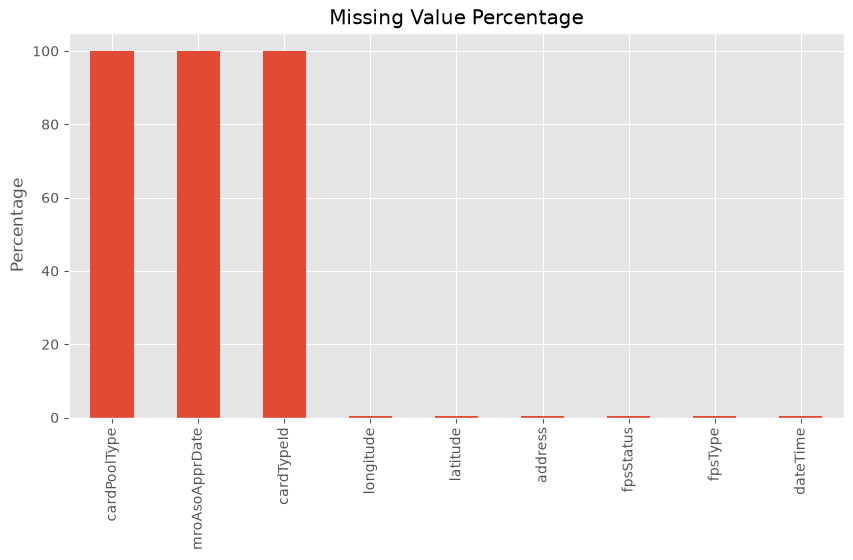

In [53]:
# ==========================================================
# Missing Value Percentage
# ==========================================================

missing = (
    final_df
    .isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing = missing[missing>0]

plt.figure(figsize=(10,5))

missing.plot(kind='bar')

plt.title("Missing Value Percentage")

plt.ylabel("Percentage")

plt.xticks(rotation=90)

plt.show()

### Observation

Only a few variables contain missing values.

### Business Insight

Columns with excessive missing values should be handled carefully before clustering to avoid introducing bias into the model.

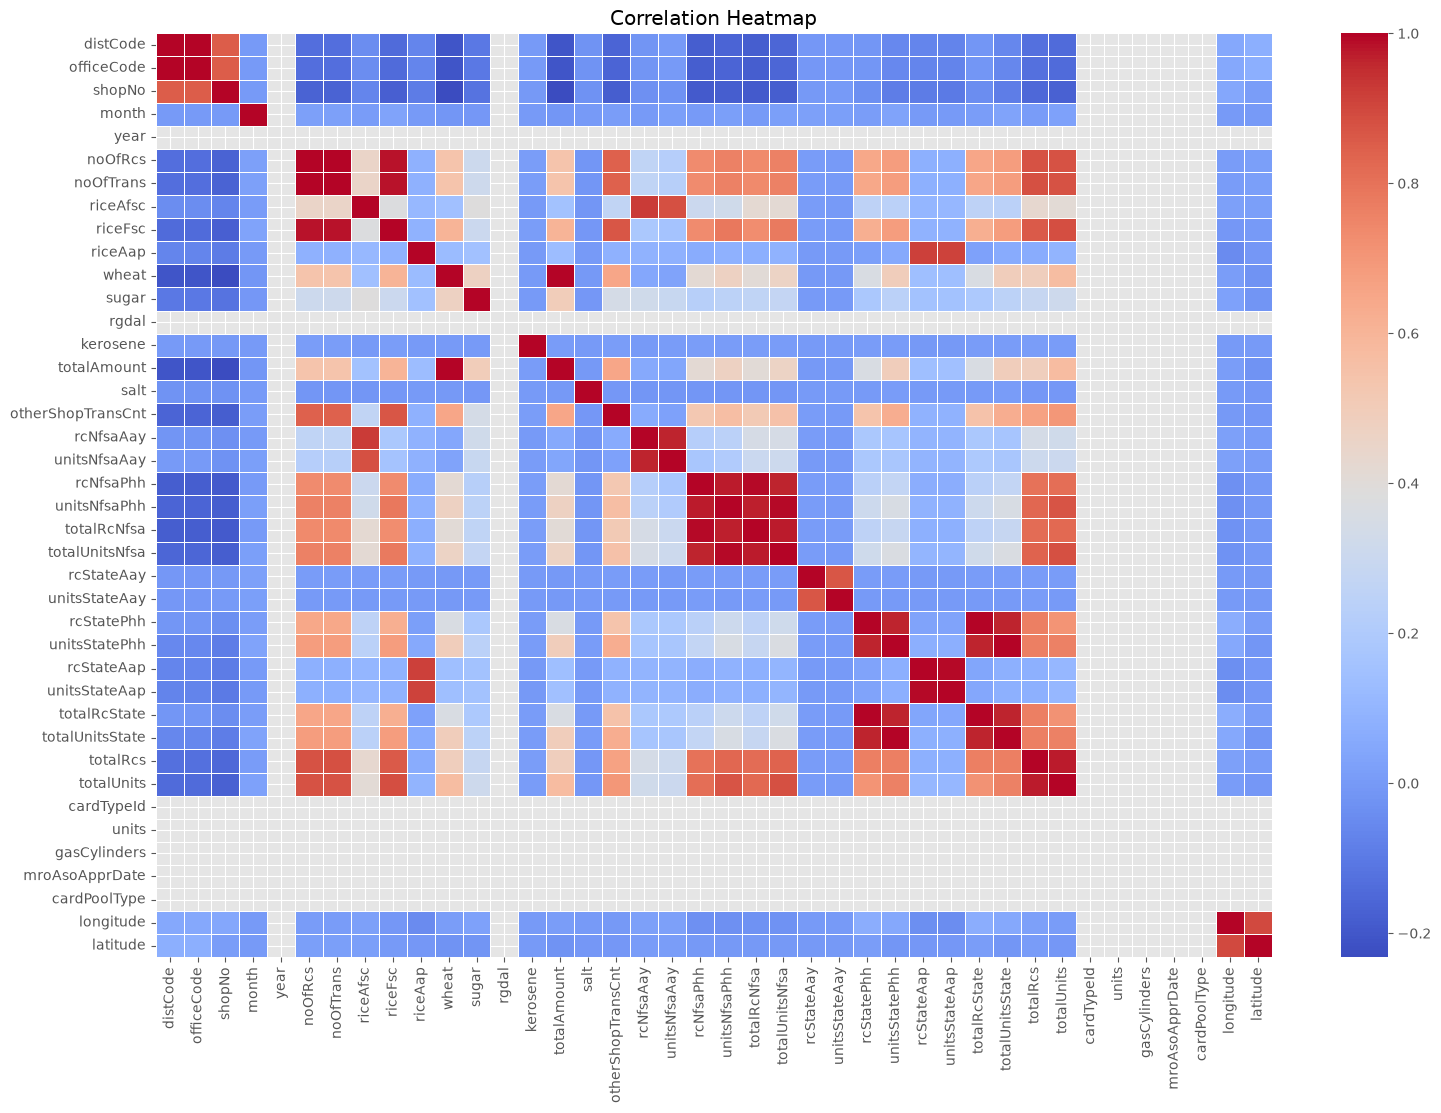

In [54]:
# ==========================================================
# Correlation Heatmap
# ==========================================================

plt.figure(figsize=(18,12))

sns.heatmap(
    final_df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm",
    linewidth=0.5
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

Several transaction-related variables exhibit strong positive correlations with total ration cards and total units.

### Business Insight

Highly correlated features may provide similar information. PCA will later help reduce redundancy before clustering.

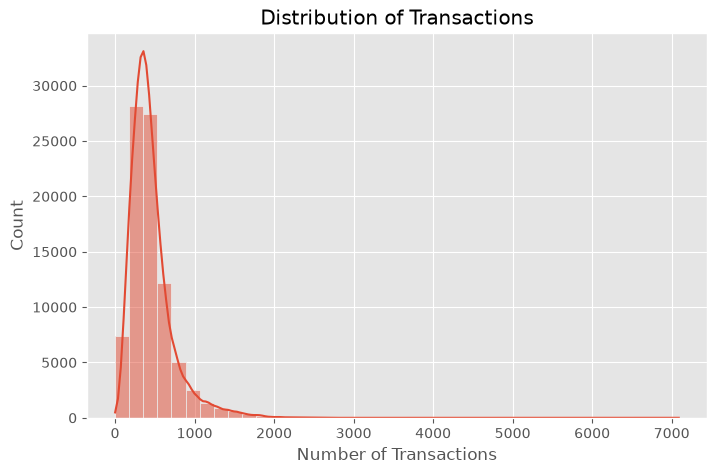

In [55]:
# ==========================================================
# Distribution of Transactions
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    final_df['noOfTrans'],
    bins=40,
    kde=True
)

plt.title("Distribution of Transactions")

plt.xlabel("Number of Transactions")

plt.show()

### Observation

Most shops process relatively fewer transactions, while a small number handle exceptionally high transaction volumes.

### Business Insight

High-volume shops may represent urban hubs or portability centers requiring more frequent stock replenishment.

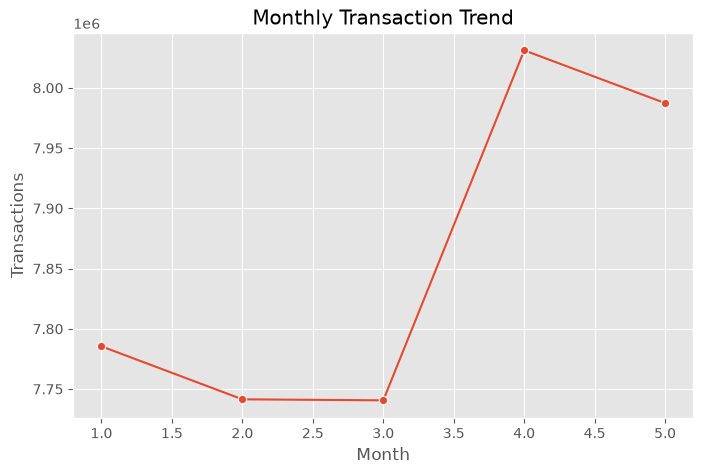

In [56]:
# ==========================================================
# Monthly Transaction Trend
# ==========================================================

monthly = (
    final_df
    .groupby("month")["noOfTrans"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.lineplot(
    data=monthly,
    x="month",
    y="noOfTrans",
    marker="o"
)

plt.title("Monthly Transaction Trend")

plt.xlabel("Month")

plt.ylabel("Transactions")

plt.show()

### Observation

Transaction volume varies across months.

### Business Insight

Monthly peaks may indicate seasonal demand, festivals, or increased beneficiary utilization.

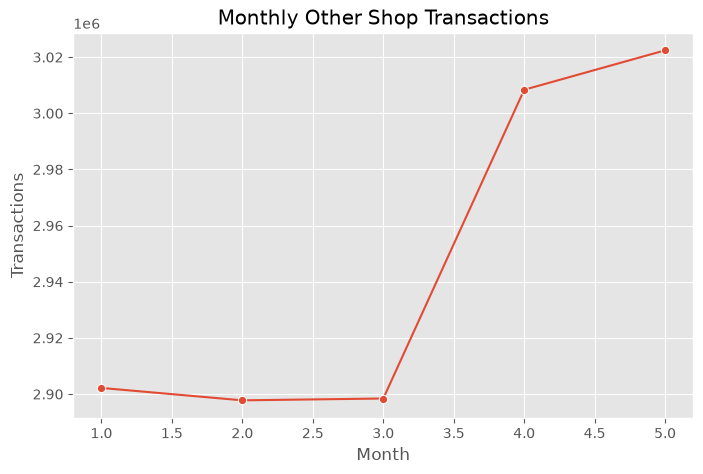

In [57]:
# ==========================================================
# Other Shop Transactions
# ==========================================================

portability = (
    final_df
    .groupby("month")["otherShopTransCnt"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.lineplot(
    data=portability,
    x="month",
    y="otherShopTransCnt",
    marker="o"
)

plt.title("Monthly Other Shop Transactions")

plt.xlabel("Month")

plt.ylabel("Transactions")

plt.show()

### Observation

The number of portability transactions changes across months.

### Business Insight

Shops with consistently high portability transactions may act as regional service hubs under the One Nation One Ration Card (ONORC) initiative.

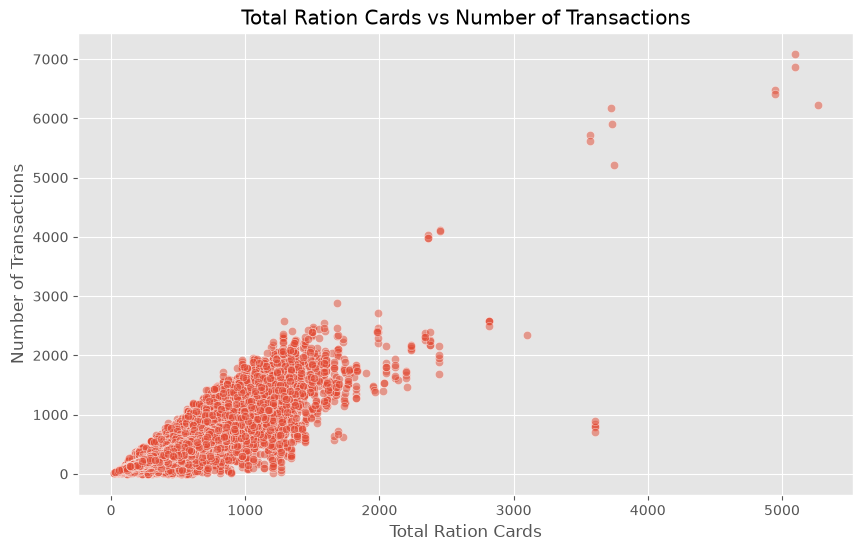

In [58]:
# ==========================================================
# Transaction vs Total Ration Cards
# ==========================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=final_df,
    x="totalRcs",
    y="noOfTrans",
    alpha=0.5
)

plt.title("Total Ration Cards vs Number of Transactions")
plt.xlabel("Total Ration Cards")
plt.ylabel("Number of Transactions")

plt.show()

### Observation

A positive relationship exists between total ration cards and transaction count.

### Business Insight

Shops serving more beneficiaries generally process more transactions. Shops that significantly deviate from this pattern may require further investigation.

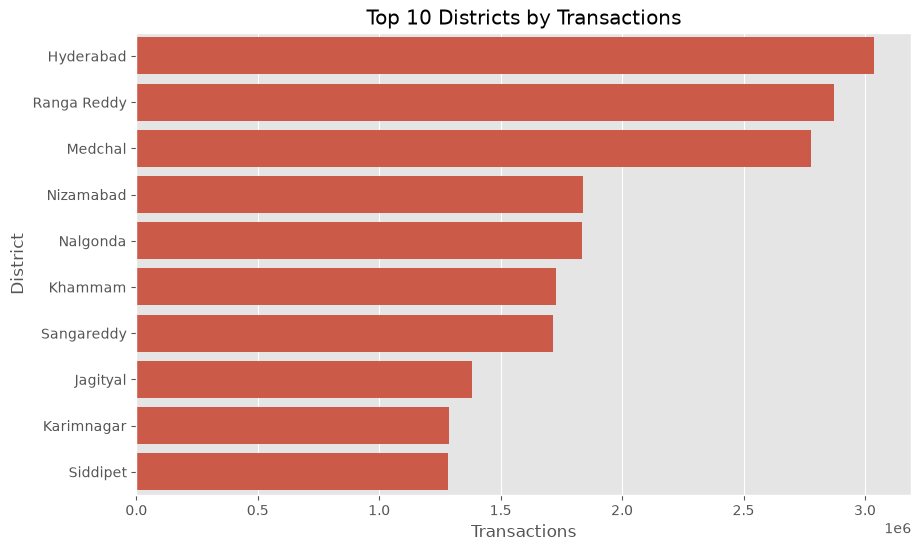

In [59]:
# ==========================================================
# Top 10 Districts by Transactions
# ==========================================================

district = (
    final_df
    .groupby("distName")["noOfTrans"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=district.values,
    y=district.index
)

plt.title("Top 10 Districts by Transactions")
plt.xlabel("Transactions")
plt.ylabel("District")

plt.show()

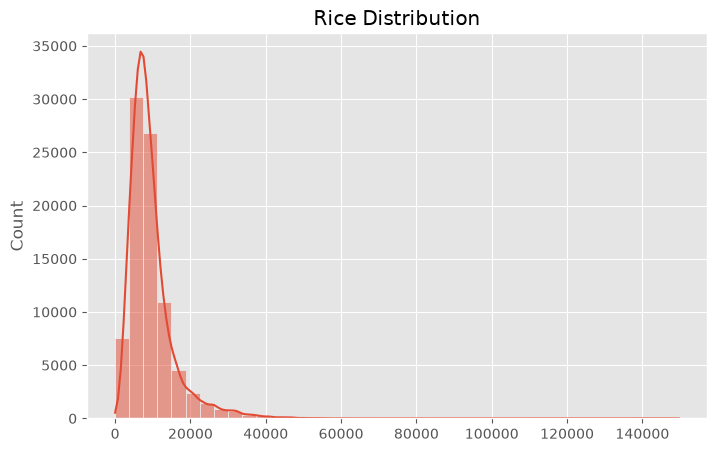

In [60]:
# ==========================================================
# Rice Distribution
# ==========================================================

rice = (
    final_df["riceAfsc"] +
    final_df["riceFsc"] +
    final_df["riceAap"]
)

plt.figure(figsize=(8,5))

sns.histplot(rice, bins=40, kde=True)

plt.title("Rice Distribution")

plt.show()

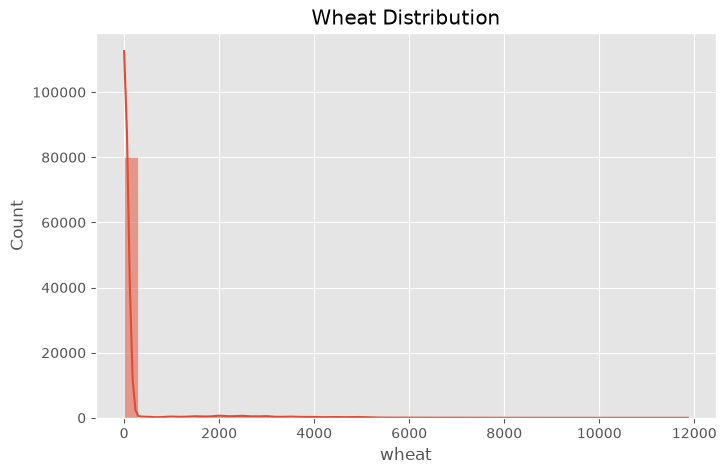

In [61]:
# ==========================================================
# Wheat Distribution
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    final_df["wheat"],
    bins=40,
    kde=True
)

plt.title("Wheat Distribution")

plt.show()

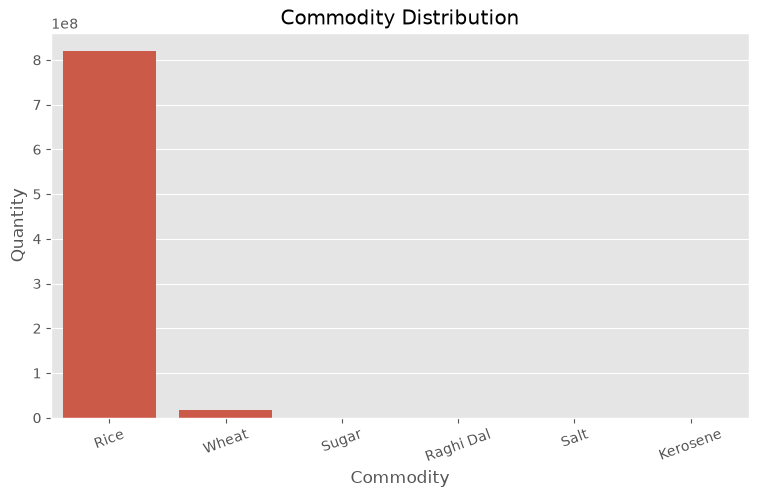

In [62]:
# ==========================================================
# Commodity Distribution
# ==========================================================

commodity = {
    "Rice": rice.sum(),
    "Wheat": final_df["wheat"].sum(),
    "Sugar": final_df["sugar"].sum(),
    "Raghi Dal": final_df["rgdal"].sum(),
    "Salt": final_df["salt"].sum(),
    "Kerosene": final_df["kerosene"].sum()
}

commodity_df = pd.DataFrame(
    commodity.items(),
    columns=["Commodity","Quantity"]
)

plt.figure(figsize=(9,5))

sns.barplot(
    data=commodity_df,
    x="Commodity",
    y="Quantity"
)

plt.title("Commodity Distribution")

plt.xticks(rotation=20)

plt.show()

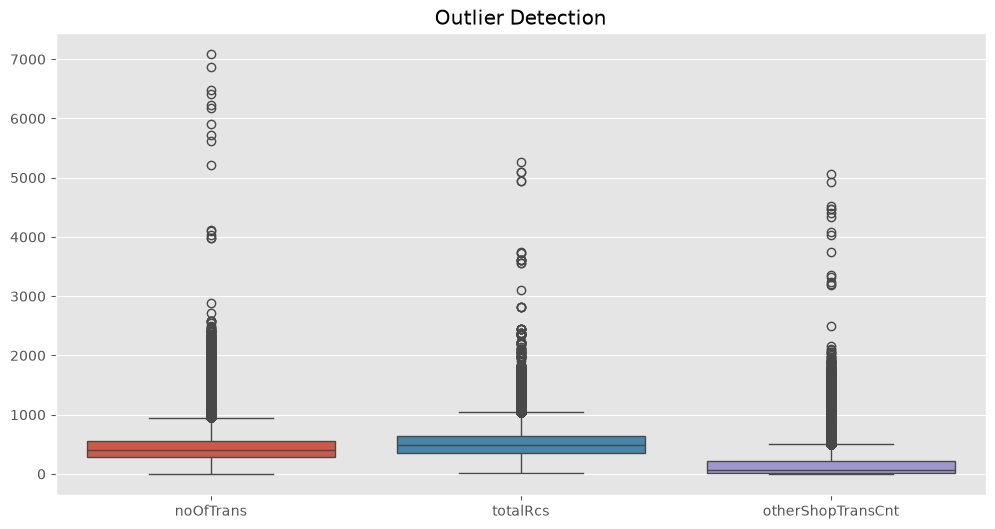

In [63]:
# ==========================================================
# Boxplot
# ==========================================================

plt.figure(figsize=(12,6))

sns.boxplot(
    data=final_df[
        [
            "noOfTrans",
            "totalRcs",
            "otherShopTransCnt"
        ]
    ]
)

plt.title("Outlier Detection")

plt.show()

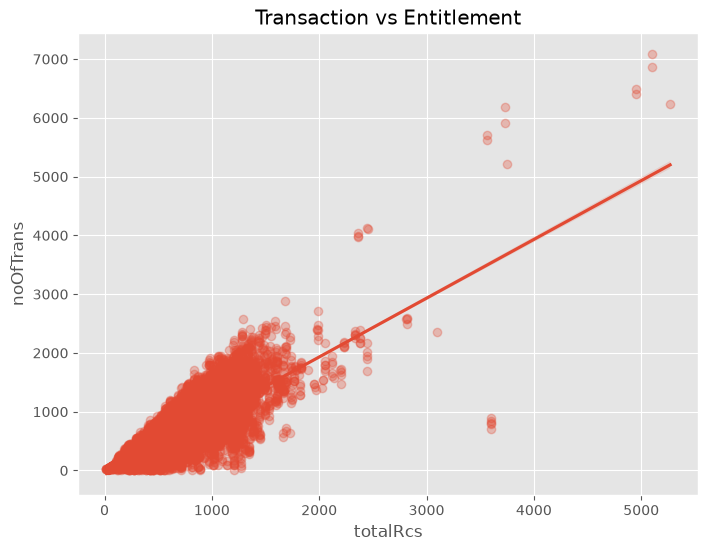

In [64]:
# ==========================================================
# Transaction vs Entitlement
# ==========================================================

plt.figure(figsize=(8,6))

sns.regplot(
    data=final_df,
    x="totalRcs",
    y="noOfTrans",
    scatter_kws={"alpha":0.3}
)

plt.title("Transaction vs Entitlement")

plt.show()

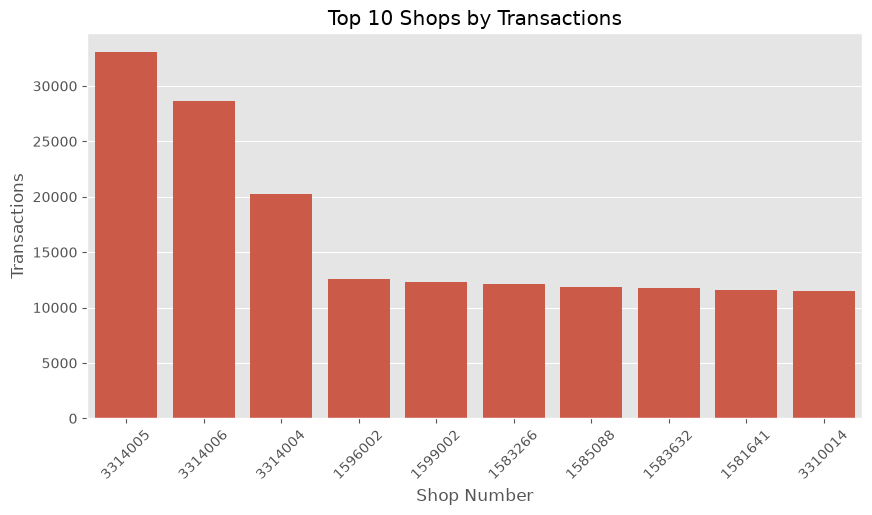

In [65]:
# ==========================================================
# Top 10 Shops
# ==========================================================

topshops = (
    final_df
    .groupby("shopNo")["noOfTrans"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=topshops.index.astype(str),
    y=topshops.values
)

plt.title("Top 10 Shops by Transactions")

plt.xlabel("Shop Number")

plt.ylabel("Transactions")

plt.xticks(rotation=45)

plt.show()

# Feature Engineering

Feature engineering transforms raw variables into meaningful business metrics that better represent shop behavior.

These engineered features help improve clustering performance and provide more interpretable shop performance indicators.

In [66]:
# ==========================================================
# Feature Engineering
# ==========================================================

# Utilization Ratio
final_df["utilization_ratio"] = (
    final_df["noOfTrans"] /
    final_df["totalRcs"].replace(0, np.nan)
)

# Rice Distribution
final_df["total_rice"] = (
    final_df["riceAfsc"] +
    final_df["riceFsc"] +
    final_df["riceAap"]
)

# Rice to Wheat Ratio
final_df["rice_wheat_ratio"] = (
    final_df["total_rice"] /
    final_df["wheat"].replace(0, np.nan)
)

# Portability Ratio
final_df["portability_ratio"] = (
    final_df["otherShopTransCnt"] /
    final_df["noOfTrans"].replace(0, np.nan)
)

# Average Units Per Card
final_df["units_per_card"] = (
    final_df["totalUnits"] /
    final_df["totalRcs"].replace(0, np.nan)
)

# Transaction Amount Per Card
final_df["amount_per_card"] = (
    final_df["totalAmount"] /
    final_df["totalRcs"].replace(0, np.nan)
)

# Commodity Intensity
final_df["commodity_intensity"] = (
    final_df["total_rice"] +
    final_df["wheat"] +
    final_df["sugar"] +
    final_df["rgdal"] +
    final_df["salt"] +
    final_df["kerosene"]
)

print("Feature Engineering Completed Successfully!")

Feature Engineering Completed Successfully!


In [67]:
# ==========================================================
# Newly Created Features
# ==========================================================

new_features = [

    "utilization_ratio",

    "total_rice",

    "rice_wheat_ratio",

    "portability_ratio",

    "units_per_card",

    "amount_per_card",

    "commodity_intensity"

]

final_df[new_features].head()

,utilization_ratio,total_rice,rice_wheat_ratio,portability_ratio,units_per_card,amount_per_card,commodity_intensity
0,0.798736,17541.0,NaN,0.031638,3.057762,0.0,17541.0
1,0.873288,10241.0,NaN,0.060784,3.205479,0.0,10241.0
2,0.904110,5403.0,NaN,0.087121,3.256849,0.0,5403.0
3,0.896296,7526.0,NaN,0.030303,3.316049,0.0,7526.0
4,0.926804,20929.0,NaN,0.036707,3.408247,0.0,20929.0


In [68]:
# ==========================================================
# Missing Values
# ==========================================================

final_df[new_features].isnull().sum()

utilization_ratio          0
total_rice                 0
rice_wheat_ratio       79669
portability_ratio          0
units_per_card             0
amount_per_card            0
commodity_intensity        0
dtype: int64

In [69]:
# ==========================================================
# Handle Missing Values
# ==========================================================

final_df[new_features] = final_df[new_features].replace(
    [np.inf, -np.inf],
    np.nan
)

final_df[new_features] = final_df[new_features].fillna(0)

print("Missing values handled successfully.")

Missing values handled successfully.


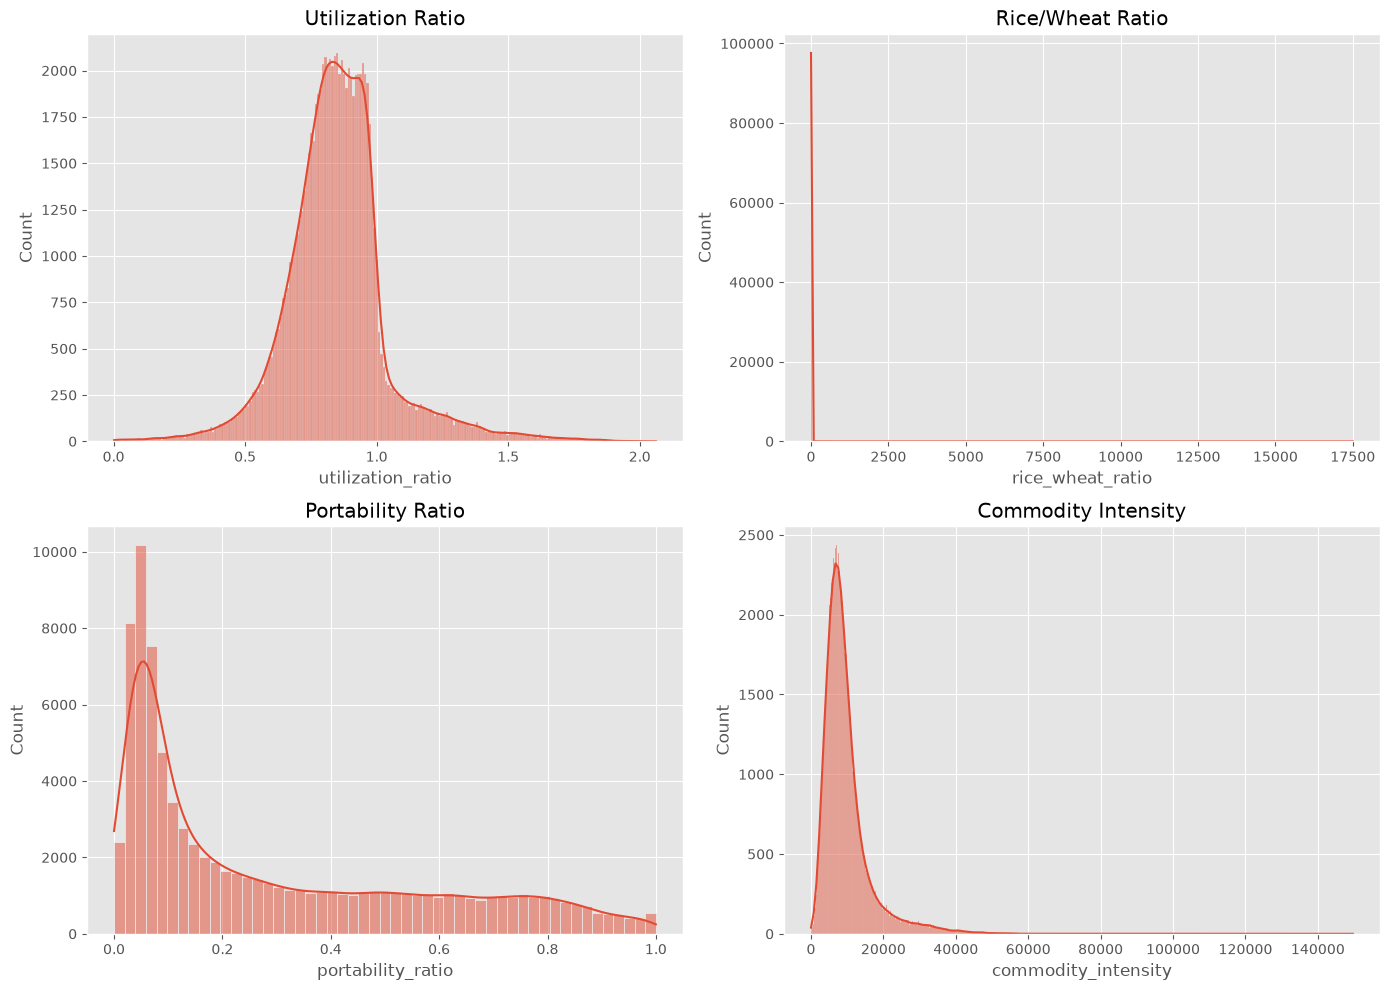

In [70]:
# ==========================================================
# Feature Distribution
# ==========================================================

fig, axes = plt.subplots(2, 2, figsize=(14,10))

sns.histplot(
    final_df["utilization_ratio"],
    kde=True,
    ax=axes[0,0]
)
axes[0,0].set_title("Utilization Ratio")

sns.histplot(
    final_df["rice_wheat_ratio"],
    kde=True,
    ax=axes[0,1]
)
axes[0,1].set_title("Rice/Wheat Ratio")

sns.histplot(
    final_df["portability_ratio"],
    kde=True,
    ax=axes[1,0]
)
axes[1,0].set_title("Portability Ratio")

sns.histplot(
    final_df["commodity_intensity"],
    kde=True,
    ax=axes[1,1]
)
axes[1,1].set_title("Commodity Intensity")

plt.tight_layout()

plt.show()

### Feature Engineering Summary

Several meaningful business features were created to better represent shop behavior.

Key engineered metrics include:

- Utilization Ratio
- Rice-Wheat Ratio
- Portability Ratio
- Units Per Card
- Amount Per Card
- Commodity Intensity

These features provide a richer representation of operational efficiency and commodity distribution, improving clustering quality.

# Data Scaling and Clustering

Distance-based clustering algorithms such as K-Means and DBSCAN are sensitive to feature scales. Therefore, all selected numerical features are standardized before applying PCA and clustering algorithms.

In [71]:
# ==========================================================
# Select Features for Clustering
# ==========================================================

cluster_features = [

    "noOfTrans",

    "totalRcs",

    "totalUnits",

    "totalAmount",

    "otherShopTransCnt",

    "total_rice",

    "wheat",

    "sugar",

    "rgdal",

    "salt",

    "kerosene",

    "utilization_ratio",

    "rice_wheat_ratio",

    "portability_ratio",

    "units_per_card",

    "amount_per_card",

    "commodity_intensity"

]

X = final_df[cluster_features]

print("Feature Matrix Shape :", X.shape)

Feature Matrix Shape : (86219, 17)


In [72]:
# ==========================================================
# Standard Scaling
# ==========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaling Completed Successfully.")

print(X_scaled.shape)

Scaling Completed Successfully.
(86219, 17)


In [73]:
# ==========================================================
# Principal Component Analysis
# ==========================================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio")

print(pca.explained_variance_ratio_)

Explained Variance Ratio
[0.48494228 0.10518603]


In [74]:
# ==========================================================
# Save PCA Components
# ==========================================================

final_df["PCA1"] = X_pca[:, 0]
final_df["PCA2"] = X_pca[:, 1]

print(final_df[["PCA1", "PCA2"]].head())

       PCA1      PCA2
0  1.899989 -2.382514
1 -0.302742 -0.581098
2 -1.707401  0.524560
3 -1.141952  0.110002
4  2.345387 -2.370818


In [75]:
# ==========================================================
# Save Updated Dataset
# ==========================================================
final_df.to_csv(
    "../data/processed/clustered_dataset.csv",
    index=False
)

print("✅ Dataset Saved Successfully")


✅ Dataset Saved Successfully


In [76]:
test = pd.read_csv("../data/processed/clustered_dataset.csv")

print(test.columns.tolist())

['distCode', 'distName', 'officeCode', 'officeName', 'shopNo', 'month', 'year', 'noOfRcs', 'noOfTrans', 'riceAfsc', 'riceFsc', 'riceAap', 'wheat', 'sugar', 'rgdal', 'kerosene', 'totalAmount', 'salt', 'otherShopTransCnt', 'rcNfsaAay', 'unitsNfsaAay', 'rcNfsaPhh', 'unitsNfsaPhh', 'totalRcNfsa', 'totalUnitsNfsa', 'rcStateAay', 'unitsStateAay', 'rcStatePhh', 'unitsStatePhh', 'rcStateAap', 'unitsStateAap', 'totalRcState', 'totalUnitsState', 'totalRcs', 'totalUnits', 'cardTypeId', 'units', 'gasCylinders', 'mroAsoApprDate', 'cardPoolType', 'address', 'longitude', 'latitude', 'fpsStatus', 'fpsType', 'dateTime', 'utilization_ratio', 'total_rice', 'rice_wheat_ratio', 'portability_ratio', 'units_per_card', 'amount_per_card', 'commodity_intensity', 'PCA1', 'PCA2']


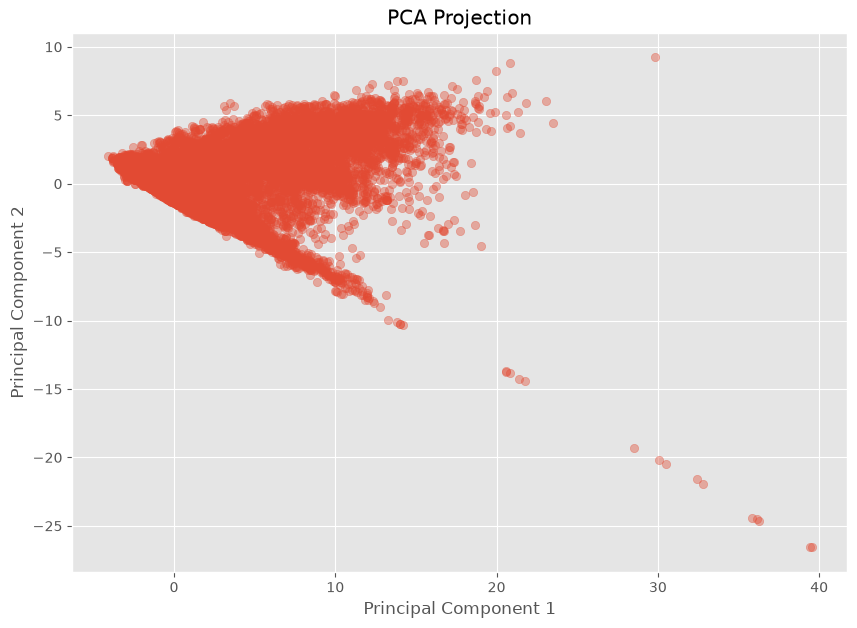

In [77]:
# ==========================================================
# PCA Scatter Plot
# ==========================================================

plt.figure(figsize=(10,7))

plt.scatter(

    X_pca[:,0],

    X_pca[:,1],

    alpha=0.4

)

plt.title("PCA Projection")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.show()

### Observation

The PCA projection reduces the high-dimensional dataset into two principal components.

### Business Insight

PCA simplifies visualization while preserving most of the important information needed for clustering.

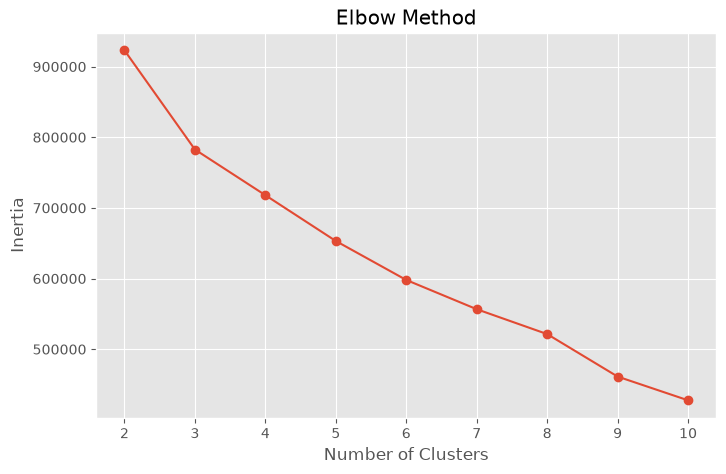

In [78]:
# ==========================================================
# Elbow Method
# ==========================================================

inertia = []

K = range(2,11)

for k in K:

    model = KMeans(

        n_clusters=k,

        random_state=42,

        n_init=10

    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(

    K,

    inertia,

    marker="o"

)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.show()

In [79]:
for k, inertia_value in zip(range(2, 11), inertia):
    print(f"k={k}: {inertia_value:.2f}")

k=2: 923042.35
k=3: 782652.35
k=4: 717991.11
k=5: 653158.30
k=6: 597991.73
k=7: 556608.91
k=8: 521392.01
k=9: 461242.08
k=10: 427647.40


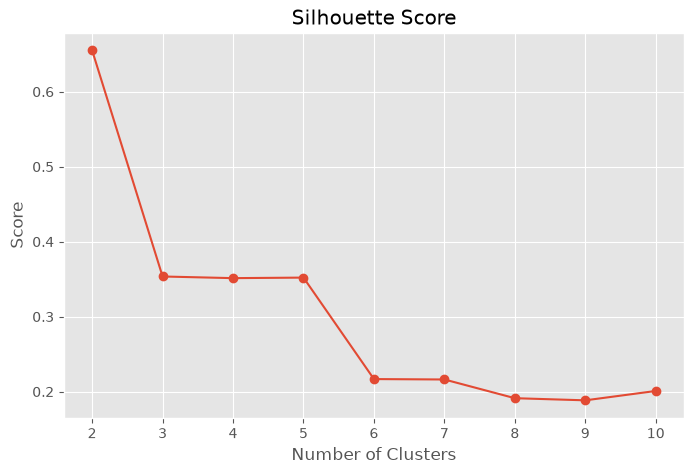

[0.6551675380384876, 0.3535606871500776, 0.35135248277904046, 0.35207609993036915, 0.2167452160295839, 0.21619964968658764, 0.19124350621396352, 0.1883978594109905, 0.20087511186961182]


In [80]:
# ==========================================================
# Silhouette Score
# ==========================================================

scores = []

K = range(2,11)

for k in K:

    model = KMeans(

        n_clusters=k,

        random_state=42,

        n_init=10

    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(

        X_scaled,

        labels

    )

    scores.append(score)

plt.figure(figsize=(8,5))

plt.plot(

    K,

    scores,

    marker="o"

)

plt.title("Silhouette Score")

plt.xlabel("Number of Clusters")

plt.ylabel("Score")

plt.show()

print(scores)

In [81]:
from sklearn.metrics import silhouette_score

sample_idx = final_df.sample(10000, random_state=42).index
X_sample = X_scaled[sample_idx]

scores = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_sample)

    score = silhouette_score(X_sample, labels)

    scores.append(score)

    print(f"k={k} --> {score:.4f}")

k=2 --> 0.6557
k=3 --> 0.3436
k=4 --> 0.3445
k=5 --> 0.3471
k=6 --> 0.2286
k=7 --> 0.1840
k=8 --> 0.2243
k=9 --> 0.2293
k=10 --> 0.2114


In [82]:
# ==========================================================
# K-Means Clustering
# ==========================================================

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

final_df["Cluster"] = kmeans.fit_predict(X_scaled)

print("K-Means Clustering Completed Successfully!")

final_df["Cluster"].value_counts().sort_index()

K-Means Clustering Completed Successfully!


Cluster
0    20723
1     4766
2    60703
3        7
4       20
Name: count, dtype: int64

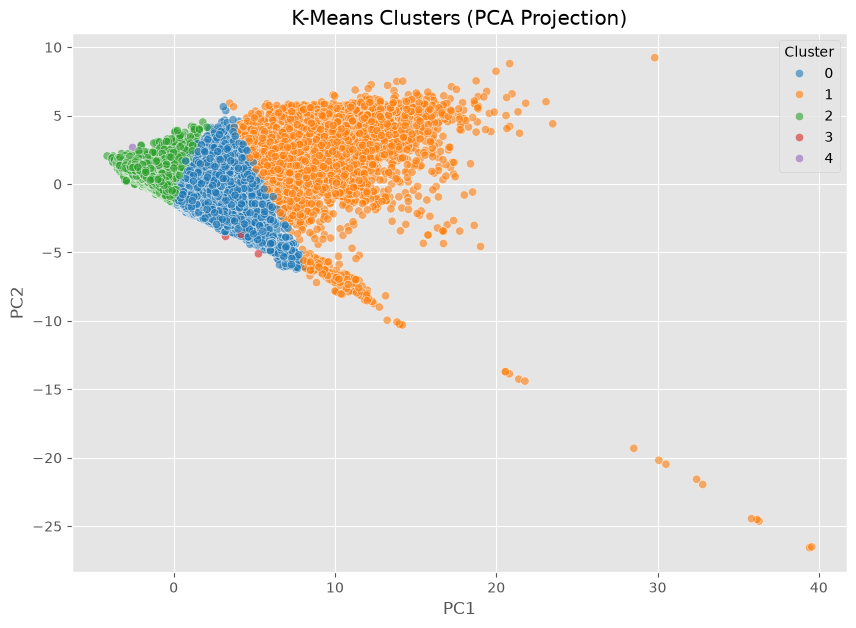

In [83]:
# ==========================================================
# PCA Cluster Visualization
# ==========================================================

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = final_df["Cluster"]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    alpha=0.6
)

plt.title("K-Means Clusters (PCA Projection)")
plt.show()

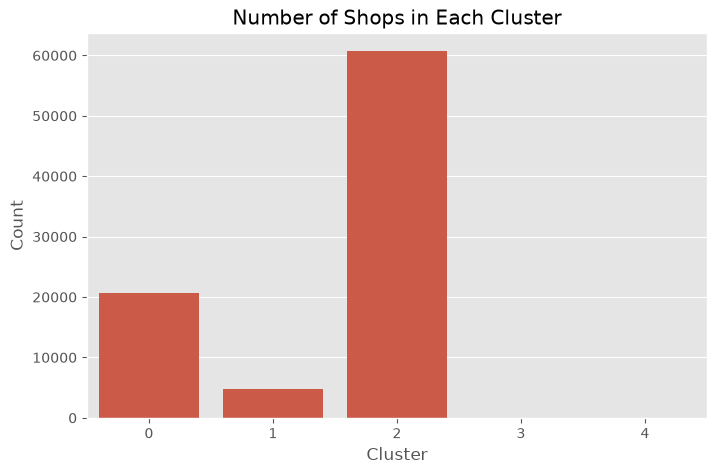

In [84]:
# ==========================================================
# Cluster Distribution
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=final_df,
    x="Cluster"
)

plt.title("Number of Shops in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")

plt.show()

In [85]:
# ==========================================================
# DBSCAN Clustering
# ==========================================================

dbscan = DBSCAN(
    eps=0.8,
    min_samples=10
)

final_df["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)

print(final_df["DBSCAN_Cluster"].value_counts())

DBSCAN_Cluster
 0     77133
-1      8237
 2       244
 3       163
 9        45
 1        40
 12       34
 6        33
 8        29
 11       23
 10       21
 13       17
 7        16
 14       15
 19       15
 17       14
 4        13
 25       13
 29       11
 18       10
 15       10
 28       10
 23       10
 20       10
 27       10
 5         8
 22        8
 21        7
 16        7
 24        7
 26        6
Name: count, dtype: int64


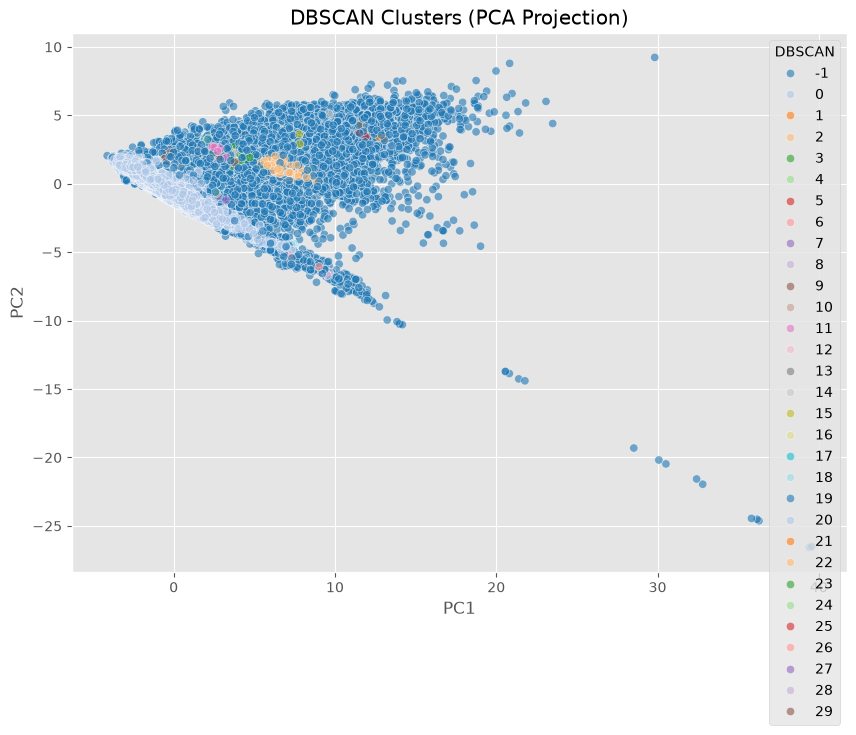

In [86]:
# ==========================================================
# DBSCAN Visualization
# ==========================================================

pca_df["DBSCAN"] = final_df["DBSCAN_Cluster"]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="DBSCAN",
    palette="tab20",
    alpha=0.6
)

plt.title("DBSCAN Clusters (PCA Projection)")
plt.show()

In [87]:
# ==========================================================
# Cluster Profiling
# ==========================================================

cluster_profile = (
    final_df
    .groupby("Cluster")[
        [
            "noOfTrans",
            "totalRcs",
            "totalAmount",
            "utilization_ratio",
            "portability_ratio",
            "commodity_intensity"
        ]
    ]
    .mean()
    .round(2)
)

cluster_profile

,noOfTrans,totalRcs,totalAmount,utilization_ratio,portability_ratio,commodity_intensity
Cluster,,,,,,
0,678.91,721.02,676.53,0.96,0.48,14288.52
1,1136.28,1042.69,22703.40,1.10,0.78,28606.53
2,326.02,416.54,48.72,0.79,0.19,6664.36
3,669.43,830.29,105.50,0.81,0.77,13766.86
4,309.20,459.75,56.92,0.68,0.21,6392.05


In [88]:
# ==========================================================
# Save Clustered Dataset
# ==========================================================

final_df.to_csv(
    "../data/processed/clustered_dataset.csv",
    index=False
)

print("Clustered dataset saved successfully!")

Clustered dataset saved successfully!


In [89]:
final_df["Cluster"].value_counts()

Cluster
2    60703
0    20723
1     4766
4       20
3        7
Name: count, dtype: int64

In [90]:
final_df["DBSCAN_Cluster"].value_counts()

DBSCAN_Cluster
 0     77133
-1      8237
 2       244
 3       163
 9        45
 1        40
 12       34
 6        33
 8        29
 11       23
 10       21
 13       17
 7        16
 14       15
 19       15
 17       14
 4        13
 25       13
 29       11
 18       10
 15       10
 28       10
 23       10
 20       10
 27       10
 5         8
 22        8
 21        7
 16        7
 24        7
 26        6
Name: count, dtype: int64

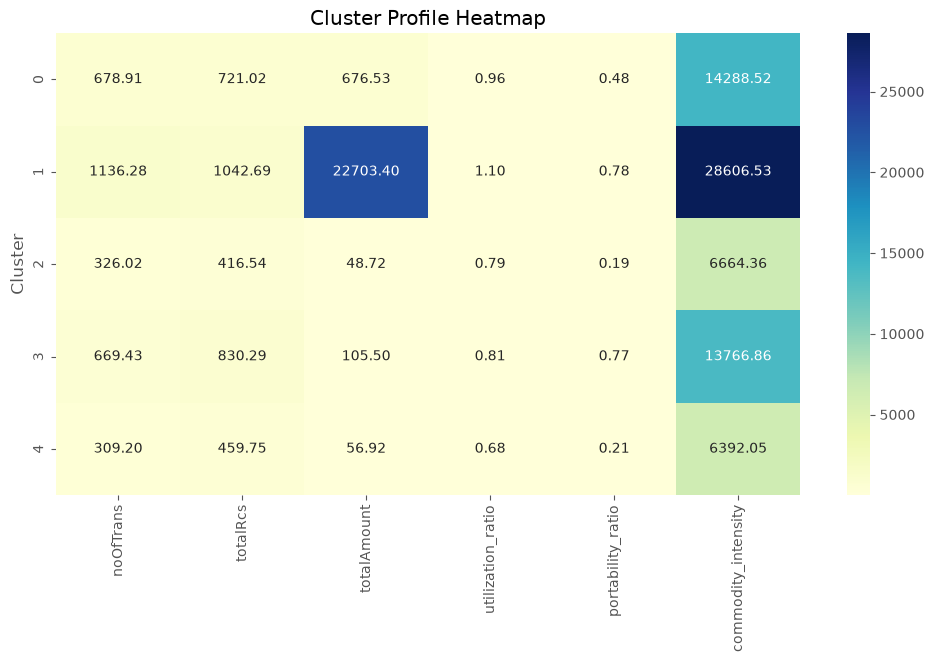

In [91]:
# ==========================================================
# Cluster Profile Heatmap
# ==========================================================

plt.figure(figsize=(12,6))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Cluster Profile Heatmap")

plt.show()

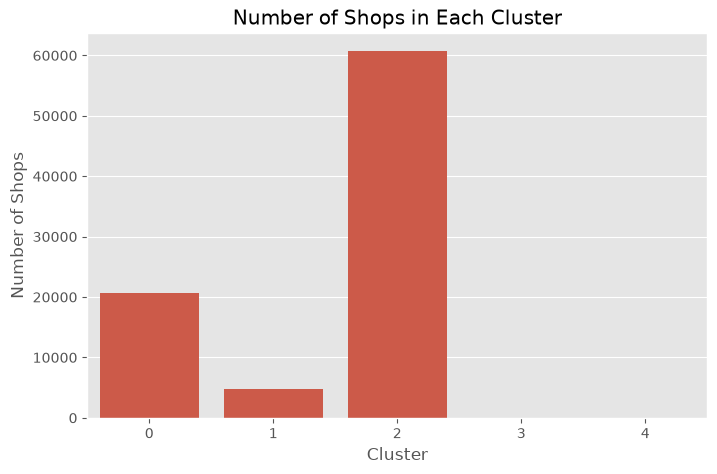

In [92]:
# ==========================================================
# Cluster Size
# ==========================================================

cluster_counts = final_df["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8,5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title("Number of Shops in Each Cluster")

plt.xlabel("Cluster")

plt.ylabel("Number of Shops")

plt.show()

In [93]:
print(final_df.shape)

(86219, 57)


In [94]:
print(final_df.columns.tolist())

['distCode', 'distName', 'officeCode', 'officeName', 'shopNo', 'month', 'year', 'noOfRcs', 'noOfTrans', 'riceAfsc', 'riceFsc', 'riceAap', 'wheat', 'sugar', 'rgdal', 'kerosene', 'totalAmount', 'salt', 'otherShopTransCnt', 'rcNfsaAay', 'unitsNfsaAay', 'rcNfsaPhh', 'unitsNfsaPhh', 'totalRcNfsa', 'totalUnitsNfsa', 'rcStateAay', 'unitsStateAay', 'rcStatePhh', 'unitsStatePhh', 'rcStateAap', 'unitsStateAap', 'totalRcState', 'totalUnitsState', 'totalRcs', 'totalUnits', 'cardTypeId', 'units', 'gasCylinders', 'mroAsoApprDate', 'cardPoolType', 'address', 'longitude', 'latitude', 'fpsStatus', 'fpsType', 'dateTime', 'utilization_ratio', 'total_rice', 'rice_wheat_ratio', 'portability_ratio', 'units_per_card', 'amount_per_card', 'commodity_intensity', 'PCA1', 'PCA2', 'Cluster', 'DBSCAN_Cluster']


# Business Recommendations

## Cluster 1 – High Performance Urban Hubs
- Ensure timely stock replenishment.
- Monitor increasing beneficiary demand.
- Use these shops as benchmark models.

## Cluster 0 – Active Service Centers
- Improve stock planning.
- Monitor portability transactions.

## Cluster 2 – Regular Neighborhood Shops
- Continue routine monitoring.
- Improve beneficiary awareness.

## Cluster 3 – High Portability Outliers
- Investigate unusual portability activity.
- Verify transaction authenticity.

## Cluster 4 – Low Utilization Shops
- Analyze reasons for under-utilization.
- Review beneficiary enrollment and accessibility.

# Conclusion

This project analyzed Telangana Fair Price Shop performance by integrating transaction, card status, and geospatial datasets.

Key achievements include:

- Integrated multiple datasets into a unified analytical dataset.
- Performed comprehensive exploratory data analysis.
- Engineered meaningful business features.
- Applied PCA for dimensionality reduction.
- Built K-Means and DBSCAN clustering models.
- Identified distinct behavioral shop personas.
- Developed an interactive Streamlit dashboard for performance monitoring.

The proposed solution can help policymakers identify high-performing shops, detect operational anomalies, improve stock planning, and support data-driven decision-making.